In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tahminahasan","key":"ae87eb4f22833b599202c1f406082d0e"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p ./data1 --unzip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:12<00:00, 196MB/s]



# **Set Seed**

In [5]:
import random
import numpy as np
import tensorflow as tf
import os

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

In [6]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/content/data1/chest_xray/train"   # adjust if different
OUTPUT_PATH = "/content/data1/chest_xray/train/train1"

# Classes in dataset
classes = ["NORMAL","PNEUMONIA"]

# Make sure output train folder exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Process each class
for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))  # replace spaces with underscore
    os.makedirs(dst_folder, exist_ok=True)

    # Get list of images
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle to randomize
    random.shuffle(images)

    # Take images
    selected_images = images[:1300]

    # Copy to train folder
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dst_folder, img))

    print(f"{cls}: {len(selected_images)} images copied to {dst_folder}")

print(" Train dataset prepared successfully!")

NORMAL: 1300 images copied to /content/data1/chest_xray/train/train1/NORMAL
PNEUMONIA: 1300 images copied to /content/data1/chest_xray/train/train1/PNEUMONIA
 Train dataset prepared successfully!


In [7]:
train_dir = "/content/data1/chest_xray/train/train1"

# **Data Visualization**

Classes: ['PNEUMONIA', 'NORMAL']


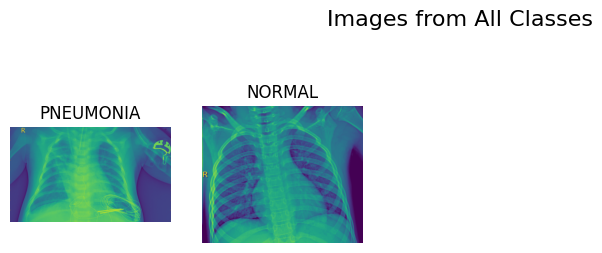

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipykernel_4432/1049858740.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=colors)
/tmp/ipykernel_4432/1049858740.py:14: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(x="label", y="count", data=df, palette=colors)


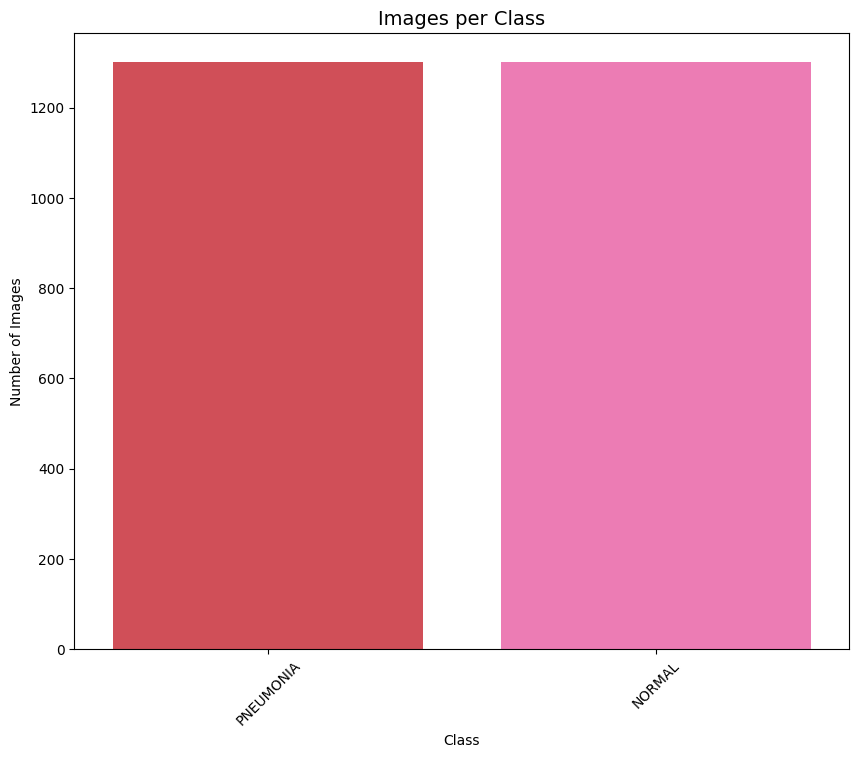

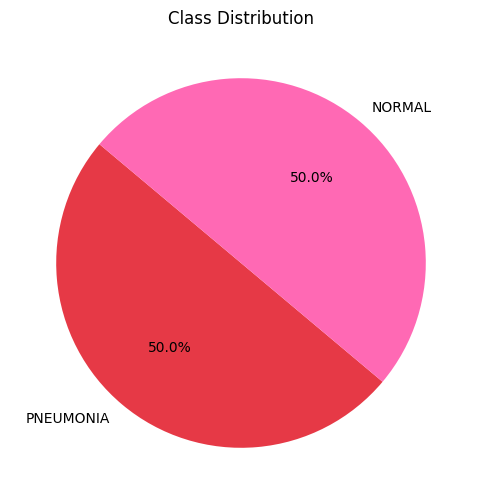

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

colors = ["#E63946", "#FF69B4","#457B9D","#2A9D8F"]

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=colors)
plt.xticks(rotation=45)
plt.title("Images per Class", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(kind="pie", autopct="%1.1f%%",
                                    startangle=140, figsize=(6,6),
                                    colors=colors)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

# **Label Encoding**

In [10]:
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

# Encoding the labels into numbers
encoder = LabelEncoder()
df["Label_num"] = encoder.fit_transform(df["label"])

# Create a list of image paths and their corresponding labels
image_paths = []
labels_num = []
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels_num.append(encoder.transform([cls])[0])

# Create a DataFrame with image paths and numerical labels
df_balanced = pd.DataFrame({"image_path": image_paths, "label_num": labels_num})

print("\nClass counts:")
print(df_balanced["label_num"].value_counts())


Class counts:
label_num
1    1300
0    1300
Name: count, dtype: int64


# **Train_Test_Split**

In [11]:
from sklearn.model_selection import train_test_split

# Ensure label_num is integer type for sparse_categorical_crossentropy
df_balanced['label_num'] = df_balanced['label_num'].astype(str)

train_df, temp_df = train_test_split(df_balanced, train_size=0.8, shuffle=True,
                                     stratify=df_balanced['label_num'], random_state=SEED)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, shuffle=True,
                                     stratify=temp_df['label_num'], random_state=SEED)

# optional shuffle for full reproducibility
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
valid_df = valid_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (2080, 2)
Validation size: (260, 2)
Test size: (260, 2)


In [12]:
print(train_df['label_num'].value_counts())

label_num
1    1040
0    1040
Name: count, dtype: int64


# **Data-Augmentation**

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input


batch_size = 32
img_size = (224, 224)

tr_gen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
    rotation_range=15,           # small rotations only
    width_shift_range=0.05,      # slight horizontal shifts
    height_shift_range=0.05,     # slight vertical shifts
    zoom_range=0.1,              # mild zoom
    horizontal_flip=True,        # flipping is okay for US images
    vertical_flip=False,         # usually vertical flip is not applied in US images
    shear_range=0.05,            # small shear
    fill_mode='nearest'          # fill empty pixels
    )

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = tr_gen.flow_from_dataframe(train_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size, seed=SEED)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size, seed=SEED)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image_path', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size, seed=SEED)

Found 2080 validated image filenames belonging to 2 classes.
Found 260 validated image filenames belonging to 2 classes.
Found 260 validated image filenames belonging to 2 classes.


# **MobileNetV3Small**

In [14]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

def create_model(input_shape=(224,224,3), num_classes=2):
    inputs = Input(shape=input_shape)

    # Pretrained  without top layers
    base = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers except last 20 for fine-tuning
    for layer in base.layers[:-20]:
        layer.trainable = False

    # Base output
    x = base.output
    x = GlobalAveragePooling2D()(x)

    # Fully connected layers
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


# Learning rate schedule (cosine decay)
lr_schedule = CosineDecay(
    initial_learning_rate=3e-4,  # starting LR
    decay_steps=1000,            # steps for one cycle
    alpha=1e-6                   # final LR fraction
)

# Create and compile model
model = create_model(num_classes=2)
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 1,368,434 (5.22 MB)

 Trainable params: 779,026 (2.97 MB)

 Non-trainable params: 589,408 (2.25 MB)

# **Labeled + Unlabeled Split**

In [15]:
from sklearn.model_selection import train_test_split

labeled_df, unlabeled_df = train_test_split(
    train_df,
    test_size=0.80,
    random_state=SEED,
    stratify=train_df["label_num"]
)

# optional reproducible shuffle after split
labeled_df = labeled_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

unlabeled_df = unlabeled_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Labeled images:", len(labeled_df))
print("Unlabeled images:", len(unlabeled_df))

# Check class distribution
print("\nClass distribution in labeled data:")
print(labeled_df["label_num"].value_counts())

print("\nClass distribution in unlabeled data:")
print(unlabeled_df["label_num"].value_counts())

Labeled images: 416
Unlabeled images: 1664

Class distribution in labeled data:
label_num
1    208
0    208
Name: count, dtype: int64

Class distribution in unlabeled data:
label_num
1    832
0    832
Name: count, dtype: int64


# **Labeled Generator (Weak Augmentation)**

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

weak_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    horizontal_flip=False,
    fill_mode='nearest'
)

labeled_gen = weak_train_datagen.flow_from_dataframe(
    labeled_df,
    x_col="image_path",
    y_col="label_num",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=SEED
)
unlabeled_gen = weak_train_datagen.flow_from_dataframe(
    unlabeled_df,
    x_col="image_path",
    y_col=None, # No labels for unlabeled data
    target_size=img_size,
    batch_size=batch_size,
    class_mode=None, # Set to None for unlabeled data
    shuffle=True,
    seed=SEED
)

Found 416 validated image filenames belonging to 2 classes.
Found 1664 validated image filenames.


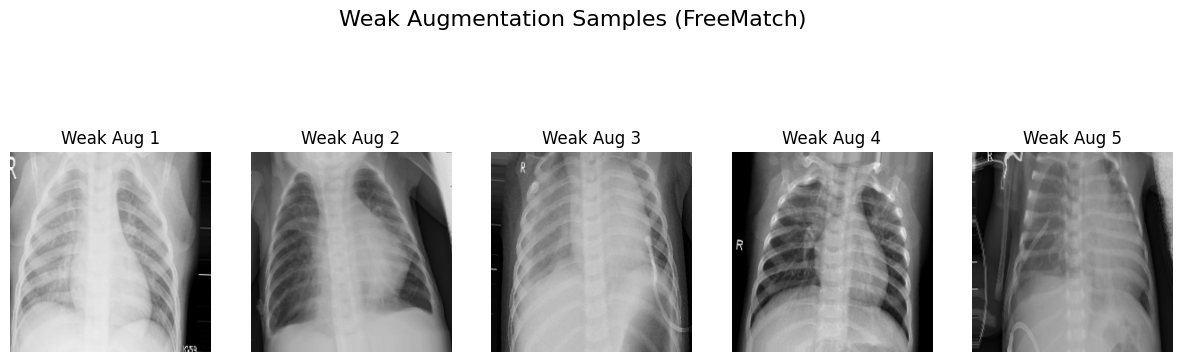

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Take 5 random samples from labeled data
samples = labeled_df.sample(5, random_state=42)['image_path'].values

plt.figure(figsize=(15,5))

for i, img_path in enumerate(samples):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)

    # Apply weak augmentation (from labeled_gen)
    aug_img = weak_train_datagen.random_transform(img.copy()) # Changed labeled_gen to weak_train_datagen

    plt.subplot(1, 5, i+1)
    plt.imshow(aug_img.astype(np.uint8))
    plt.title(f"Weak Aug {i+1}")
    plt.axis('off')

plt.suptitle("Weak Augmentation Samples (FreeMatch)", fontsize=16)
plt.show()

# **FreeMatch Strong Augmentation Function**

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


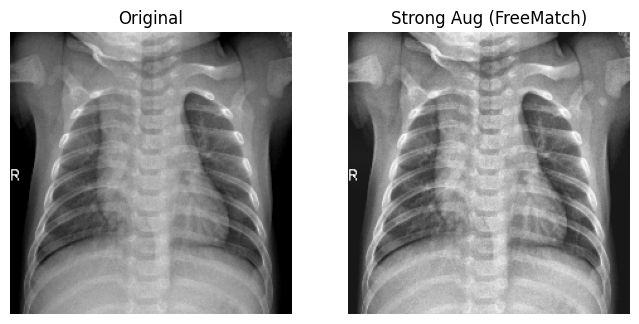

In [18]:
import albumentations as A
import cv2
import numpy as np

strong_transform = A.Compose([
    A.Rotate(limit=8, p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=8,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.6),
    A.CLAHE(p=0.5),
    A.Blur(blur_limit=3, p=0.2),
    A.RandomResizedCrop(
        size=img_size,
        scale=(0.9,1.0),
        p=0.5
    )
])

def apply_strong(img):
    augmented = strong_transform(image=img)
    out = augmented['image']
    out = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
    return out

# Example visualization
sample = train_df.sample(1).iloc[0]['image_path']
orig = cv2.cvtColor(cv2.imread(sample), cv2.COLOR_BGR2RGB)
orig = cv2.resize(orig, img_size)
strong_sample = apply_strong(orig.copy())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(orig); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(strong_sample); plt.title("Strong Aug (FreeMatch)"); plt.axis('off')
plt.show()

# **FreeMatch Training Loop**

In [19]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# ============================================================
# FREEMATCH TRAINING FUNCTION
# ============================================================

def run_freematch_training_once():

    # ========================================================
    # HYPERPARAMETERS
    # ========================================================

    warmup_epochs = 3
    epochs = 5

    num_classes = len(train_df['label_num'].unique())

    best_val_acc = -np.inf

    optimizer = tf.keras.optimizers.Adam(3e-4)

    ce_loss = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    )

    lambda_u_max = 1.0

    # ========================================================
    # FREEMATCH VARIABLES
    # ========================================================

    # global adaptive threshold
    tau = tf.Variable(0.90, dtype=tf.float32)

    # EMA momentum
    ema_m = 0.999

    # class distribution tracker
    p_model = tf.Variable(
        tf.ones([num_classes]) / num_classes,
        dtype=tf.float32
    )

    # ========================================================
    # METRICS
    # ========================================================

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    supervised_losses, unsupervised_losses = [], []
    pseudo_accept_rates = []

    # ========================================================
    # WARMUP PHASE
    # ========================================================

    print("\nStarting Warmup Phase...\n")

    for epoch in range(warmup_epochs):

        print(f"\nWarmup Epoch {epoch+1}/{warmup_epochs}")

        losses, correct, total = [], 0, 0

        prog_bar = tqdm(range(len(labeled_gen)),
                        desc="Warmup",
                        ncols=100)

        for _ in prog_bar:

            lx, ly = next(labeled_gen)

            with tf.GradientTape() as tape:

                preds = model(lx, training=True)

                loss = ce_loss(ly, preds)

            grads = tape.gradient(
                loss,
                model.trainable_variables
            )

            optimizer.apply_gradients(
                zip(grads, model.trainable_variables)
            )

            losses.append(loss.numpy())

            correct += np.sum(
                np.argmax(preds.numpy(), axis=1) == ly
            )

            total += lx.shape[0]

            prog_bar.set_postfix({
                "loss": f"{np.mean(losses):.4f}",
                "acc": f"{correct/total:.4f}"
            })

        val_loss, val_acc = model.evaluate(valid_gen, verbose=0)

        print(
            f"Warmup {epoch+1}: "
            f"loss={np.mean(losses):.4f}, "
            f"val_acc={val_acc:.4f}"
        )

    print("\nWarmup Completed ✔")

    # ========================================================
    # FREEMATCH PHASE
    # ========================================================

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        epoch_losses = []
        sup_losses = []
        unsup_losses = []

        correct, total = 0, 0

        accepted, total_pseudo = 0, 0

        # ramp-up
        lambda_u = lambda_u_max * (
            epoch / max(1, epochs)
        )

        prog_bar = tqdm(
            range(len(labeled_gen)),
            desc="Training",
            ncols=100
        )

        for _ in prog_bar:

            lx, ly = next(labeled_gen)
            ux = next(unlabeled_gen)

            with tf.GradientTape() as tape:

                # ====================================================
                # SUPERVISED
                # ====================================================

                pred_l = model(lx, training=True)

                loss_super = ce_loss(ly, pred_l)

                # ====================================================
                # WEAK PREDICTION
                # ====================================================

                weak_pred = model(ux, training=False)

                pseudo_prob = tf.reduce_max(
                    weak_pred,
                    axis=1
                )

                pseudo_label = tf.argmax(
                    weak_pred,
                    axis=1
                )

                # ====================================================
                # UPDATE EMA DISTRIBUTION
                # ====================================================

                batch_mean = tf.reduce_mean(
                    weak_pred,
                    axis=0
                )

                p_model.assign(
                    ema_m * p_model +
                    (1 - ema_m) * batch_mean
                )

                # ====================================================
                # FREEMATCH ADAPTIVE THRESHOLD
                # ====================================================

                mean_conf = tf.reduce_mean(
                    pseudo_prob
                )

                tau.assign(
                    ema_m * tau +
                    (1 - ema_m) * mean_conf
                )

                # class fairness scaling
                class_factor = tf.gather(
                    p_model,
                    pseudo_label
                )

                adaptive_thresh = tau * class_factor

                mask = pseudo_prob >= adaptive_thresh

                accepted += tf.reduce_sum(
                    tf.cast(mask, tf.int32)
                ).numpy()

                total_pseudo += ux.shape[0]

                # ====================================================
                # STRONG AUGMENTATION
                # ====================================================

                loss_unsuper = 0.0

                if tf.reduce_sum(
                    tf.cast(mask, tf.int32)
                ) > 0:

                    ux_raw = (
                        (ux * 0.5 + 0.5) * 255
                    ).astype(np.uint8)

                    ux_strong = np.stack([
                        apply_strong(img)
                        for img in ux_raw
                    ])

                    ux_strong = preprocess_input(
                        ux_strong
                    )

                    strong_pred = model(
                        ux_strong,
                        training=True
                    )

                    loss_unsuper = ce_loss(
                        tf.boolean_mask(
                            pseudo_label,
                            mask
                        ),
                        tf.boolean_mask(
                            strong_pred,
                            mask
                        )
                    )

                # ====================================================
                # FAIRNESS REGULARIZATION
                # ====================================================

                pred_mean = tf.reduce_mean(
                    weak_pred,
                    axis=0
                )

                uniform_dist = tf.ones_like(
                    pred_mean
                ) / num_classes

                fairness_loss = tf.reduce_mean(
                    tf.square(
                        pred_mean - uniform_dist
                    )
                )

                # ====================================================
                # TOTAL LOSS
                # ====================================================

                total_loss = (
                    loss_super +
                    lambda_u * loss_unsuper +
                    0.01 * fairness_loss
                )

            # ========================================================
            # BACKPROP
            # ========================================================

            grads = tape.gradient(
                total_loss,
                model.trainable_variables
            )

            optimizer.apply_gradients(
                zip(grads, model.trainable_variables)
            )

            # ========================================================
            # METRICS
            # ========================================================

            epoch_losses.append(total_loss.numpy())

            sup_losses.append(loss_super.numpy())

            unsup_losses.append(
                loss_unsuper.numpy()
                if isinstance(loss_unsuper, tf.Tensor)
                else loss_unsuper
            )

            correct += np.sum(
                np.argmax(pred_l.numpy(), axis=1) == ly
            )

            total += lx.shape[0]

            prog_bar.set_postfix({
                "loss": f"{np.mean(epoch_losses):.4f}",
                "acc": f"{correct/total:.4f}",
                "mask": f"{accepted/max(total_pseudo,1):.2f}",
                "tau": f"{tau.numpy():.3f}",
                "λu": f"{lambda_u:.2f}"
            })

        # ========================================================
        # VALIDATION
        # ========================================================

        val_loss, val_acc = model.evaluate(
            valid_gen,
            verbose=0
        )

        train_losses.append(np.mean(epoch_losses))
        train_accuracies.append(correct / total)

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        supervised_losses.append(np.mean(sup_losses))
        unsupervised_losses.append(np.mean(unsup_losses))

        pseudo_accept_rates.append(
            accepted / max(total_pseudo, 1)
        )

        print(
            f"Epoch {epoch+1}: "
            f"loss={np.mean(epoch_losses):.4f}, "
            f"sup={np.mean(sup_losses):.4f}, "
            f"unsup={np.mean(unsup_losses):.4f}, "
            f"val_acc={val_acc:.4f}"
        )

        # ========================================================
        # SAVE BEST MODEL
        # ========================================================

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            model.save("best_freematch.keras")

            print("Model improved ✔ saved")

        # ========================================================
        # PRINT THRESHOLD
        # ========================================================

        print(f"Adaptive Threshold τ: {tau.numpy():.4f}")

    return (
        best_val_acc,
        train_losses,
        train_accuracies,
        val_losses,
        val_accuracies,
        supervised_losses,
        unsupervised_losses,
        pseudo_accept_rates
    )


# ============================================================
# MULTI RUN
# ============================================================

results = []

# Global metric storage
all_train_losses = []
all_train_acc = []

all_val_losses = []
all_val_acc = []

all_supervised_losses = []
all_unsupervised_losses = []

all_pseudo_accept_rates = []

runs = 3

for i in range(runs):

    print("\n" + "=" * 60)
    print(f"RUN {i+1}/{runs}")
    print("=" * 60)

    (
        best_val_acc,
        train_losses_run,
        train_accuracies_run,
        val_losses_run,
        val_accuracies_run,
        supervised_losses_run,
        unsupervised_losses_run,
        pseudo_accept_rates_run
    ) = run_freematch_training_once()

    results.append(best_val_acc)

    # store metrics
    all_train_losses.append(train_losses_run)
    all_train_acc.append(train_accuracies_run)

    all_val_losses.append(val_losses_run)
    all_val_acc.append(val_accuracies_run)

    all_supervised_losses.append(
        supervised_losses_run
    )

    all_unsupervised_losses.append(
        unsupervised_losses_run
    )

    all_pseudo_accept_rates.append(
        pseudo_accept_rates_run
    )

# ============================================================
# FINAL REPORT
# ============================================================

results = np.array(results)

print("\n================ FINAL RESULTS ================")

print(f"Accuracies: {results}")

print(f"Mean: {np.mean(results):.4f}")

print(f"Std: {np.std(results):.4f}")

print(
    f"Mean ± Std: "
    f"{np.mean(results):.4f} ± "
    f"{np.std(results):.4f}"
)


RUN 1/3

Starting Warmup Phase...


Warmup Epoch 1/3


Warmup: 100%|██████████████████████████████| 13/13 [00:19<00:00,  1.50s/it, loss=0.6420, acc=0.7308]


Warmup 1: loss=0.6420, val_acc=0.5000

Warmup Epoch 2/3


Warmup: 100%|██████████████████████████████| 13/13 [00:15<00:00,  1.16s/it, loss=0.2637, acc=0.8942]


Warmup 2: loss=0.2637, val_acc=0.5038

Warmup Epoch 3/3


...

Epoch 3: loss=0.4258, sup=0.0446, unsup=0.9524, val_acc=0.9500
Adaptive Threshold τ: 0.9017

Epoch 4/5


Training: 100%|█| 13/13 [00:34<00:00,  2.66s/it, loss=0.5943, acc=0.9784, mask=1.00, tau=0.902, λu=0


Epoch 4: loss=0.5943, sup=0.0423, unsup=0.9196, val_acc=0.8962
Adaptive Threshold τ: 0.9019

Epoch 5/5


Training: 100%|█| 13/13 [00:34<00:00,  2.67s/it, loss=0.7713, acc=0.9639, mask=1.00, tau=0.902, λu=0


Epoch 5: loss=0.7713, sup=0.0989, unsup=0.8399, val_acc=0.9538
Adaptive Threshold τ: 0.9016

================ FINAL RESULTS ================
Accuracies: [0.93461537 0.96923077 0.96923077]
Mean: 0.9577
Std: 0.0163
Mean ± Std: 0.9577 ± 0.0163


# **Evaluation on Test Set**

In [20]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label_num",
    target_size=img_size,
    class_mode="sparse",
    shuffle=False,
    batch_size=batch_size
)

y_true = test_gen.classes
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)


Found 260 validated image filenames belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 900ms/step



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       130
           1       0.95      0.98      0.97       130

    accuracy                           0.97       260
   macro avg       0.97      0.97      0.97       260
weighted avg       0.97      0.97      0.97       260



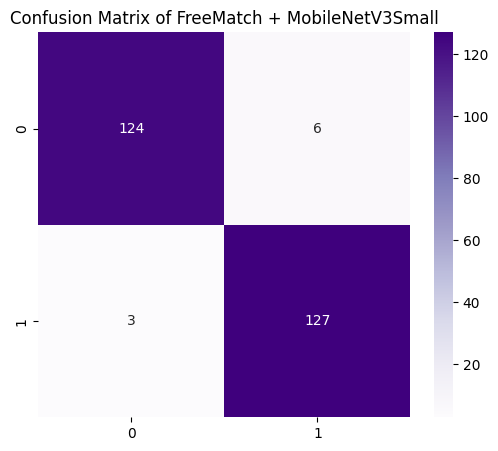

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix of FreeMatch + MobileNetV3Small")
plt.show()

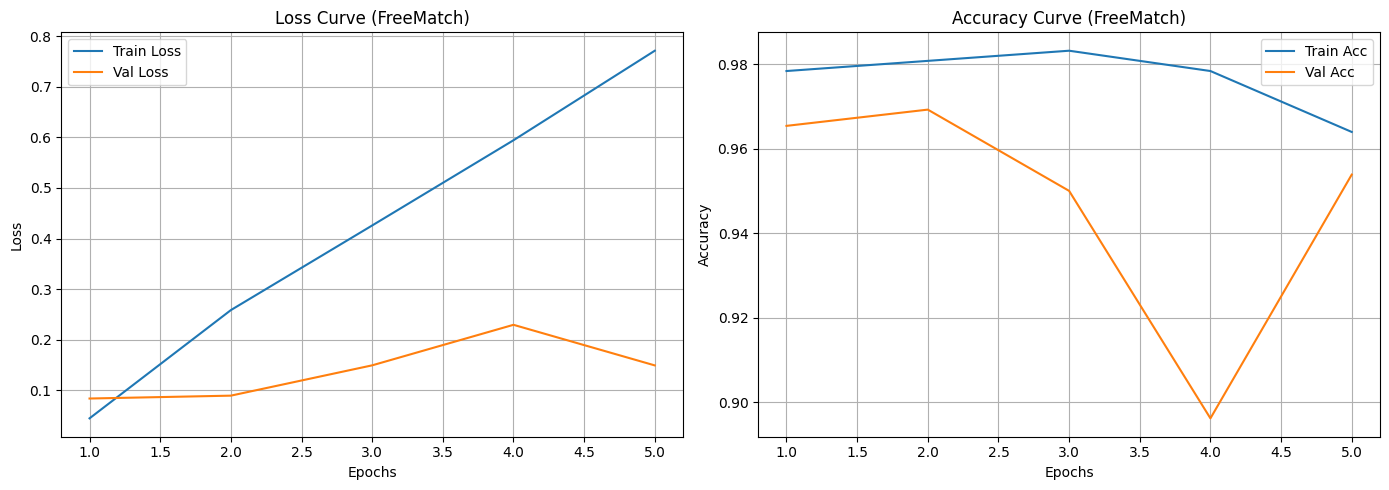

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# TAKE LAST RUN (same as your style)
# ============================================================

train_loss = np.array(all_train_losses[-1])
val_loss = np.array(all_val_losses[-1])

train_acc = np.array(all_train_acc[-1])
val_acc = np.array(all_val_acc[-1])

epochs = np.arange(1, len(train_loss) + 1)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- LOSS ----------------
ax[0].plot(epochs, train_loss, label="Train Loss")
ax[0].plot(epochs, val_loss, label="Val Loss")

ax[0].set_title("Loss Curve (FreeMatch)")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# ---------------- ACCURACY ----------------
ax[1].plot(epochs, train_acc, label="Train Acc")
ax[1].plot(epochs, val_acc, label="Val Acc")

ax[1].set_title("Accuracy Curve (FreeMatch)")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

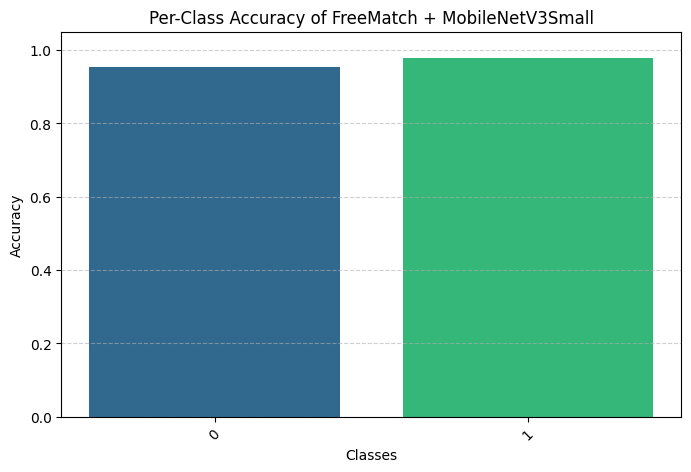

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8,5))

colors = sns.color_palette("viridis", len(class_names))

plt.bar(class_names, class_acc, color=colors)

plt.title("Per-Class Accuracy of FreeMatch + MobileNetV3Small")
plt.xlabel("Classes")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

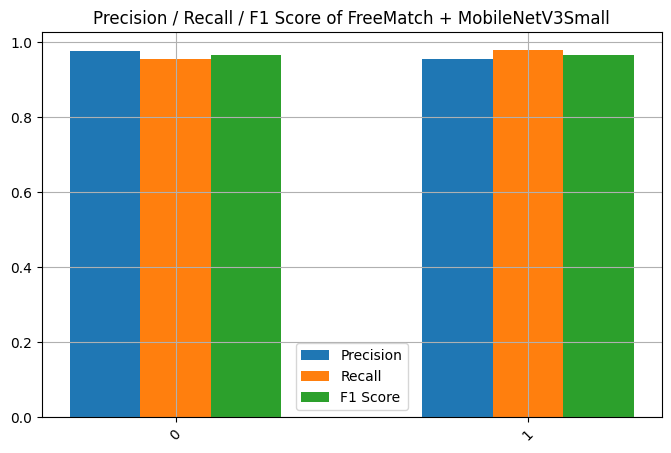

In [24]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred)

x = np.arange(len(class_names))

plt.figure(figsize=(8,5))
plt.bar(x-0.2, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar(x+0.2, f1, width=0.2, label="F1 Score")

plt.xticks(x, class_names, rotation=45)
plt.title("Precision / Recall / F1 Score of FreeMatch + MobileNetV3Small")
plt.legend()
plt.grid(True)
plt.show()

# **AUC-ROC**

In [25]:
y_prob = model.predict(test_gen)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step


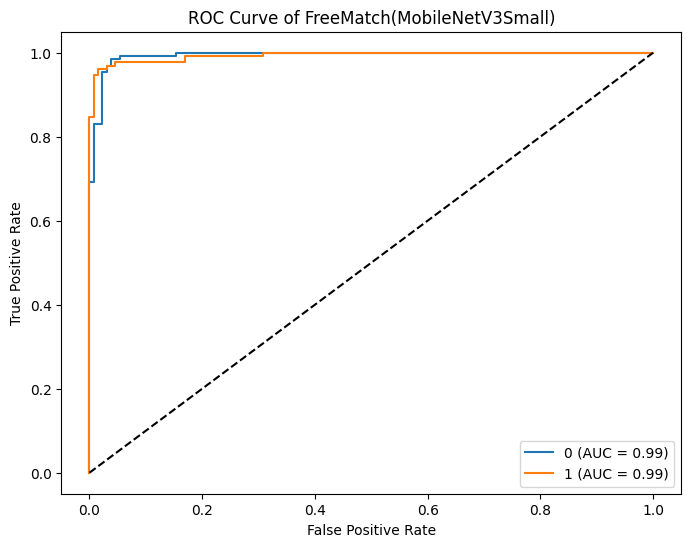

In [26]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Number of classes
class_names = list(test_gen.class_indices.keys())
n_classes = len(class_names)

# True labels
y_true = np.array(test_gen.classes) # Converted to NumPy array here

# Predicted probabilities (softmax outputs)
y_prob = model.predict(test_gen)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    # For each class, treat it as the positive class
    # Convert y_true to binary labels (1 if it's class i, 0 otherwise)
    y_true_for_class_i = (y_true == i).astype(int)

    # Use the probabilities for class i
    y_score_for_class_i = y_prob[:, i]

    fpr, tpr, _ = roc_curve(y_true_for_class_i, y_score_for_class_i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Random chance line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve of FreeMatch(MobileNetV3Small)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# **MONTE CARLO DROPOUT & CALIBRATION**


Running MC Dropout on 5 batches (Batch Size = 32)...


100%|██████████| 5/5 [00:58<00:00, 11.77s/it]


================ MC DROPOUT RESULTS ================

Average Uncertainty : 0.1239
Minimum Uncertainty : 0.0001
Maximum Uncertainty : 0.6903
MC Dropout Accuracy : 0.9563


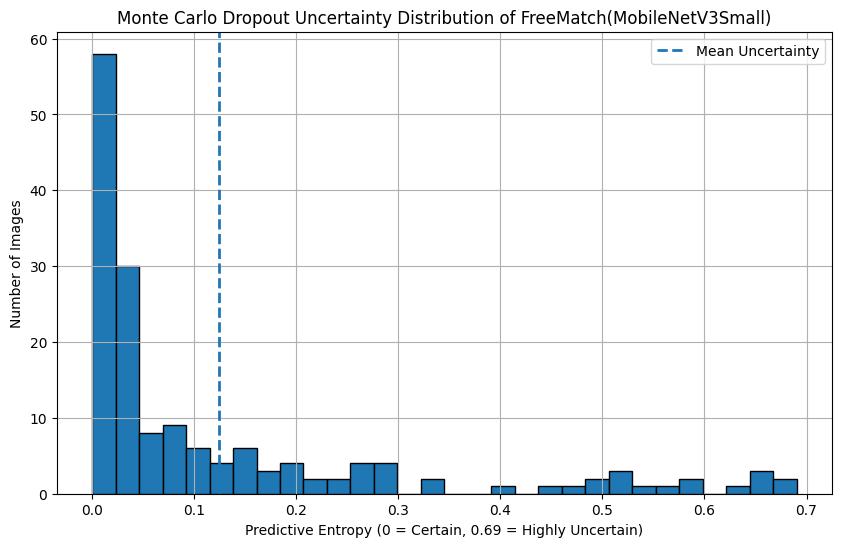


================ UNCERTAINTY THRESHOLDING ================

Threshold : 0.3
Flagged For Expert Review : 12.50%
Accuracy on Certain Predictions : 0.9857
Accuracy on Uncertain Predictions : 0.7500


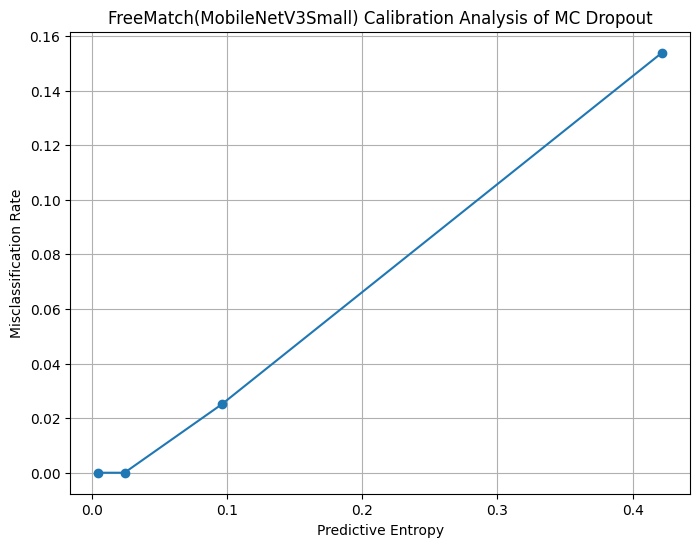

In [27]:
# =========================================================
# MONTE CARLO DROPOUT (MC DROPOUT)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import accuracy_score

# =========================================================
# MC DROPOUT FUNCTION
# =========================================================

def mc_dropout_predict_batch(
    model,
    generator,
    T=50,
    num_batches=5
):

    """
    Performs Monte Carlo Dropout inference.

    Parameters:
    -----------
    model : trained keras model

    generator : test generator

    T : number of stochastic forward passes

    num_batches : number of batches to evaluate

    Returns:
    --------
    mean_predictions
    uncertainties
    true_labels
    predicted_labels
    """

    all_mean_preds = []

    all_uncertainties = []

    all_true_labels = []

    all_pred_labels = []

    # iterator
    data_iter = iter(generator)

    print(
        f"\nRunning MC Dropout on "
        f"{num_batches} batches "
        f"(Batch Size = {generator.batch_size})..."
    )

    for batch_idx in tqdm(range(num_batches)):

        # =====================================================
        # LOAD BATCH
        # =====================================================

        imgs, labels = next(data_iter)

        # =====================================================
        # STORE PREDICTIONS
        # Shape:
        # (T, batch_size, num_classes)
        # =====================================================

        batch_preds = []

        for _ in range(T):

            # IMPORTANT:
            # training=True activates dropout
            preds = model(
                imgs,
                training=True
            )

            batch_preds.append(preds.numpy())

        batch_preds = np.array(batch_preds)

        # =====================================================
        # MEAN PREDICTION
        # =====================================================

        mean_preds = np.mean(
            batch_preds,
            axis=0
        )

        # =====================================================
        # PREDICTED CLASS
        # =====================================================

        pred_labels = np.argmax(
            mean_preds,
            axis=1
        )

        # =====================================================
        # PREDICTIVE ENTROPY
        # =====================================================

        epsilon = 1e-8

        entropy = -np.sum(
            mean_preds * np.log(mean_preds + epsilon),
            axis=1
        )

        # =====================================================
        # STORE RESULTS
        # =====================================================

        all_mean_preds.extend(mean_preds)

        all_uncertainties.extend(entropy)

        all_true_labels.extend(labels)

        all_pred_labels.extend(pred_labels)

    return (
        np.array(all_mean_preds),
        np.array(all_uncertainties),
        np.array(all_true_labels),
        np.array(all_pred_labels)
    )


# =========================================================
# RUN MC DROPOUT
# =========================================================

mean_preds, uncertainties, true_labels, pred_labels = mc_dropout_predict_batch(
    model=model,
    generator=test_gen,
    T=50,
    num_batches=5
)

# =========================================================
# STATISTICS
# =========================================================

print("\n================ MC DROPOUT RESULTS ================\n")

print(f"Average Uncertainty : {np.mean(uncertainties):.4f}")

print(f"Minimum Uncertainty : {np.min(uncertainties):.4f}")

print(f"Maximum Uncertainty : {np.max(uncertainties):.4f}")

accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print(f"MC Dropout Accuracy : {accuracy:.4f}")

# =========================================================
# UNCERTAINTY HISTOGRAM
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    uncertainties,
    bins=30,
    edgecolor='black'
)

plt.axvline(
    np.mean(uncertainties),
    linestyle='dashed',
    linewidth=2,
    label='Mean Uncertainty'
)

plt.xlabel(
    "Predictive Entropy "
    "(0 = Certain, 0.69 = Highly Uncertain)"
)

plt.ylabel("Number of Images")

plt.title(
    "Monte Carlo Dropout Uncertainty Distribution of FreeMatch(MobileNetV3Small)"
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# UNCERTAINTY THRESHOLDING
# =========================================================

threshold = 0.30

certain_mask = uncertainties < threshold

uncertain_mask = uncertainties >= threshold

# certain predictions
certain_acc = accuracy_score(
    true_labels[certain_mask],
    pred_labels[certain_mask]
)

# uncertain predictions
uncertain_acc = accuracy_score(
    true_labels[uncertain_mask],
    pred_labels[uncertain_mask]
)

print("\n================ UNCERTAINTY THRESHOLDING ================\n")

print(f"Threshold : {threshold}")

print(
    f"Flagged For Expert Review : "
    f"{100*np.mean(uncertain_mask):.2f}%"
)

print(
    f"Accuracy on Certain Predictions : "
    f"{certain_acc:.4f}"
)

print(
    f"Accuracy on Uncertain Predictions : "
    f"{uncertain_acc:.4f}"
)

# =========================================================
# CALIBRATION ANALYSIS
# =========================================================

quartiles = np.percentile(
    uncertainties,
    [25, 50, 75]
)

bins = [
    uncertainties.min(),
    quartiles[0],
    quartiles[1],
    quartiles[2],
    uncertainties.max()
]

error_rates = []

bin_centers = []

for i in range(len(bins)-1):

    mask = (
        (uncertainties >= bins[i]) &
        (uncertainties < bins[i+1])
    )

    if np.sum(mask) > 0:

        error = np.mean(
            pred_labels[mask] != true_labels[mask]
        )

        error_rates.append(error)

        bin_centers.append(
            (bins[i] + bins[i+1]) / 2
        )

# =========================================================
# CALIBRATION PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(
    bin_centers,
    error_rates,
    marker='o'
)

plt.xlabel("Predictive Entropy")

plt.ylabel("Misclassification Rate")

plt.title(
    "FreeMatch(MobileNetV3Small) Calibration Analysis of MC Dropout"
)

plt.grid(True)

plt.show()

# **ACCURACY COMPARISON PLOT**

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step


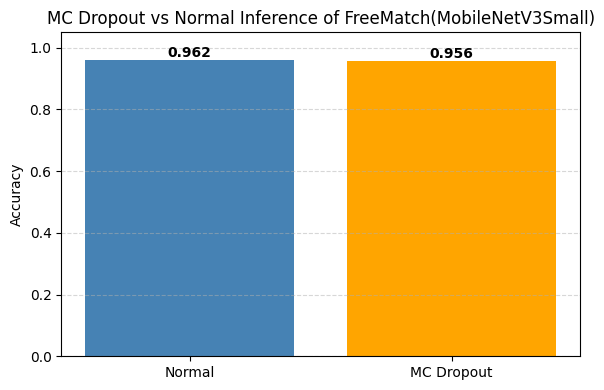

In [28]:
normal_preds = np.argmax(model.predict(test_gen), axis=1)
normal_labels = y_true

normal_acc = accuracy_score(normal_labels, normal_preds)
mc_acc = accuracy

labels = ["Normal", "MC Dropout"]
accs = [normal_acc, mc_acc]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, accs, color=["steelblue", "orange"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}",
             ha='center', fontweight='bold')

plt.title("MC Dropout vs Normal Inference of FreeMatch(MobileNetV3Small)")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **UNCERTAINTY vs CORRECTNESS**

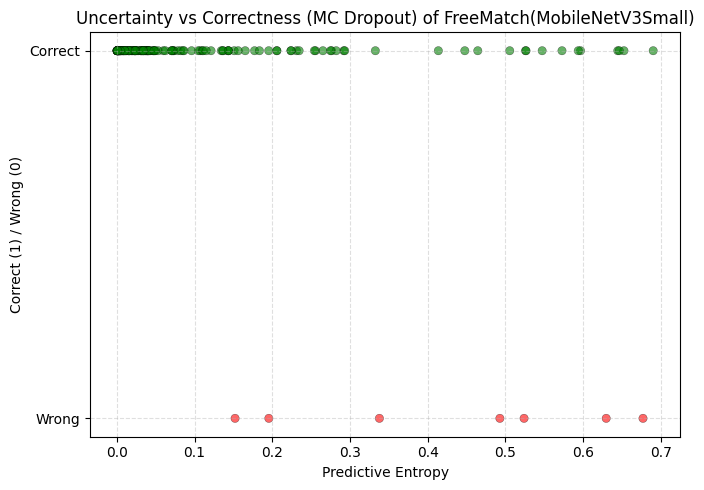

In [29]:
correct = (pred_labels == true_labels)

colors = np.where(correct, "green", "red")

plt.figure(figsize=(7,5))

plt.scatter(
    uncertainties,
    correct.astype(int),
    c=colors,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

plt.title("Uncertainty vs Correctness (MC Dropout) of FreeMatch(MobileNetV3Small)")
plt.xlabel("Predictive Entropy")
plt.ylabel("Correct (1) / Wrong (0)")
plt.yticks([0,1], ["Wrong", "Correct"])
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# **THRESHOLD ANALYSIS**

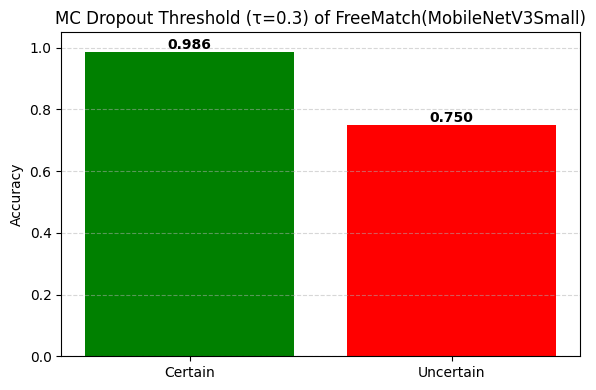

In [30]:
threshold = 0.30

certain = uncertainties < threshold
uncertain = uncertainties >= threshold

certain_acc = accuracy_score(true_labels[certain], pred_labels[certain])
uncertain_acc = accuracy_score(true_labels[uncertain], pred_labels[uncertain])

labels = ["Certain", "Uncertain"]
accs = [certain_acc, uncertain_acc]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, accs, color=["green", "red"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}",
             ha='center', fontweight='bold')

plt.title(f"MC Dropout Threshold (τ={threshold}) of FreeMatch(MobileNetV3Small)")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


================ SAMPLE DISTRIBUTION ================

Total Samples        : 160
Certain Samples      : 140 (87.50%)
Uncertain Samples    : 20 (12.50%)


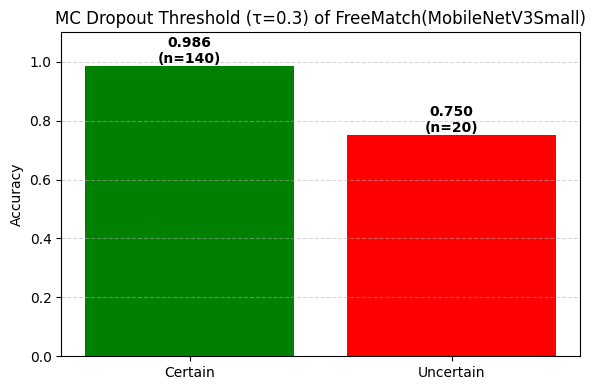

In [31]:
# =========================================================
# NUMBER OF CERTAIN / UNCERTAIN SAMPLES
# =========================================================

num_certain = np.sum(certain)
num_uncertain = np.sum(uncertain)

total_samples = len(uncertainties)

print("\n================ SAMPLE DISTRIBUTION ================\n")

print(f"Total Samples        : {total_samples}")

print(
    f"Certain Samples      : "
    f"{num_certain} "
    f"({100*num_certain/total_samples:.2f}%)"
)

print(
    f"Uncertain Samples    : "
    f"{num_uncertain} "
    f"({100*num_uncertain/total_samples:.2f}%)"
)
plt.figure(figsize=(6,4))

bars = plt.bar(labels, accs, color=["green", "red"])

sample_counts = [num_certain, num_uncertain]

for i, bar in enumerate(bars):

    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f"{h:.3f}\n(n={sample_counts[i]})",
        ha='center',
        fontweight='bold'
    )

plt.title(
    f"MC Dropout Threshold (τ={threshold}) "
    f"of FreeMatch(MobileNetV3Small)"
)

plt.ylabel("Accuracy")

plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

# **TTA**

TTA Accuracy: 0.9538


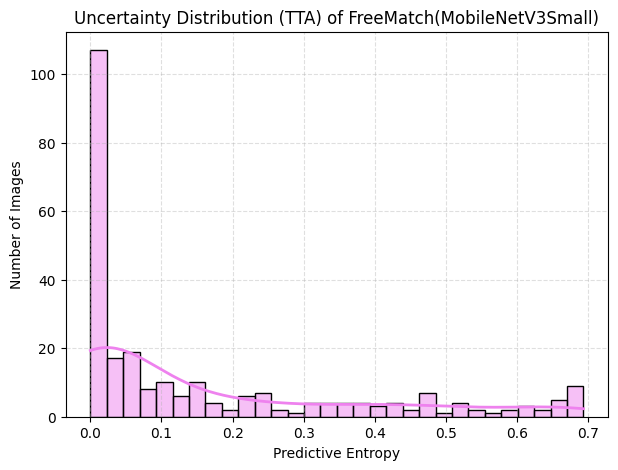

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# TTA parameters
# -----------------------------
tta_steps = 10
img_size = (224, 224)
batch_size = 32

# -----------------------------
# Strong augmentation function (MixMatch style)
# -----------------------------
def apply_strong(img):
    # Ensure RGB and resize
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)

    # Example strong augmentations for MixMatch
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)  # horizontal flip
    factor = 0.9 + 0.2 * np.random.rand()  # brightness [0.9,1.1]
    img = np.clip(img * factor, 0, 255).astype(np.uint8)

    return img

# -----------------------------
# Prepare test images
# -----------------------------
image_paths = test_df['image_path'].tolist()
all_probs = []

for step in range(tta_steps):
    batch_images = []
    for path in image_paths:
        img = cv2.imread(path)
        img_aug = apply_strong(img)
        batch_images.append(img_aug)

    batch_images = np.stack(batch_images, axis=0)
    batch_images = preprocess_input(batch_images)

    # Predict probabilities
    probs = model.predict(batch_images, batch_size=batch_size, verbose=0)
    all_probs.append(probs)

# -----------------------------
# Average predictions across TTA
# -----------------------------
y_prob_tta = np.mean(all_probs, axis=0)
y_pred_tta = np.argmax(y_prob_tta, axis=1)

# True labels
y_true = test_gen.classes

# Compute TTA accuracy
tta_acc = np.mean(y_pred_tta == y_true)
print(f"TTA Accuracy: {tta_acc:.4f}")

# -----------------------------
# Predictive entropy for uncertainty
# -----------------------------
entropy = -np.sum(y_prob_tta * np.log(y_prob_tta + 1e-8), axis=1)

# Plot histogram of predictive entropy
plt.figure(figsize=(7,5))
sns.histplot(entropy, bins=30, kde=True, color="violet",
             line_kws={"linewidth": 2, "color": "violet"})
plt.title("Uncertainty Distribution (TTA) of FreeMatch(MobileNetV3Small)")
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Images")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# **TTA Improvement Comparison Plot**

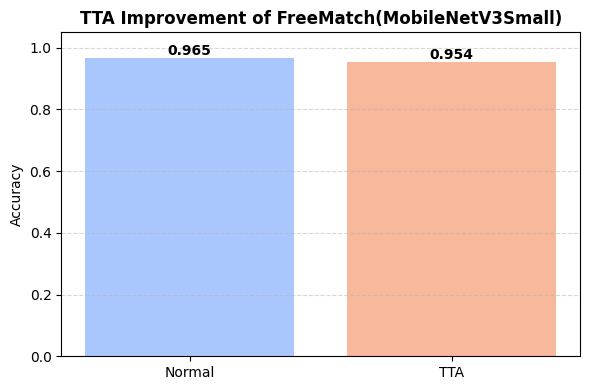

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

normal_acc = np.mean(y_pred == y_true)
tta_acc = np.mean(y_pred_tta == y_true)

accs = [normal_acc, tta_acc]
labels = ["Normal", "TTA"]

colors = sns.color_palette("coolwarm", 2)

plt.figure(figsize=(6,4))

bars = plt.bar(labels, accs, color=colors, linewidth=1.2)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.3f}",
             ha='center', fontsize=10, fontweight='bold')

plt.title("TTA Improvement of FreeMatch(MobileNetV3Small)",
          fontsize=12, fontweight='bold')

plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **Uncertainty vs Accuracy Analysis**

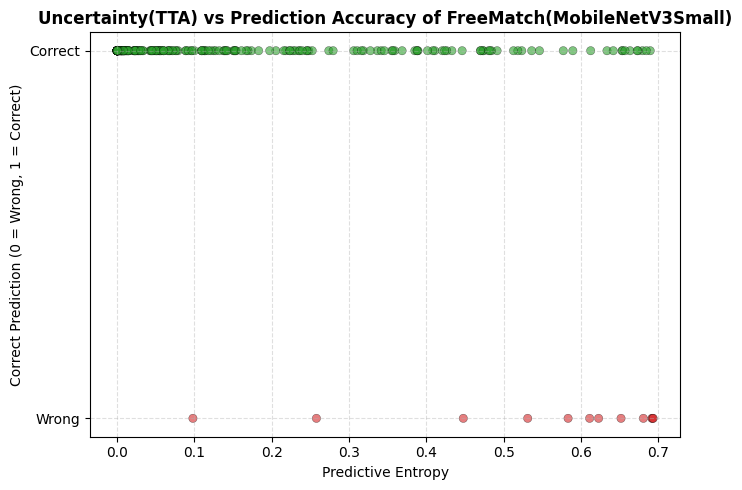

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

correct = (y_pred_tta == y_true)

plt.figure(figsize=(7,5))

# Color by correctness (very useful for analysis)
colors = np.where(correct, "#2ca02c", "#d62728")  # green = correct, red = wrong

plt.scatter(entropy, correct, c=colors, alpha=0.6, edgecolor='black', linewidth=0.3)

plt.title("Uncertainty(TTA) vs Prediction Accuracy of FreeMatch(MobileNetV3Small)",
          fontsize=12, fontweight='semibold')

plt.xlabel("Predictive Entropy")
plt.ylabel("Correct Prediction (0 = Wrong, 1 = Correct)")

plt.yticks([0, 1], ["Wrong", "Correct"])

plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# **Prediction Confidence Distribution**

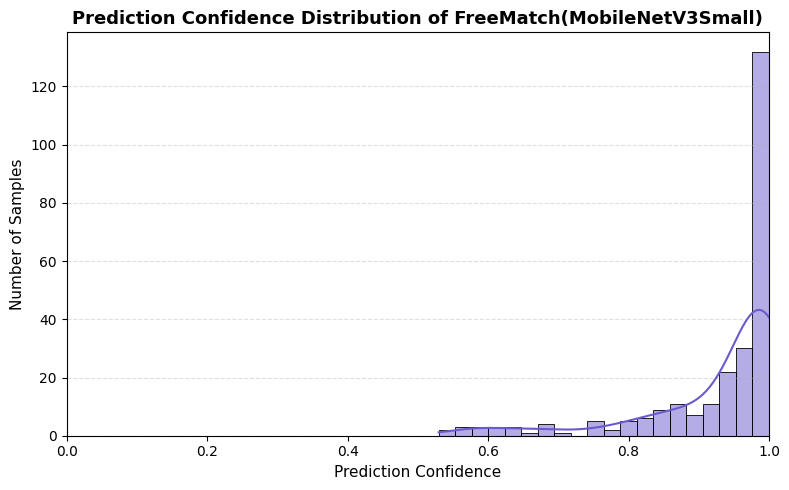

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

confidence = np.max(y_prob, axis=1)

plt.figure(figsize=(8,5))

# Histogram with KDE overlay for smooth distribution
sns.histplot(confidence,
             bins=20,
             kde=True,
             color="#6a5acd",
             edgecolor="black",
             linewidth=0.6)

# Styling
plt.title("Prediction Confidence Distribution of FreeMatch(MobileNetV3Small)",
          fontsize=13, fontweight='bold')

plt.xlabel("Prediction Confidence", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)

plt.xlim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# **ECE**


ECE (Expected Calibration Error): 0.0163


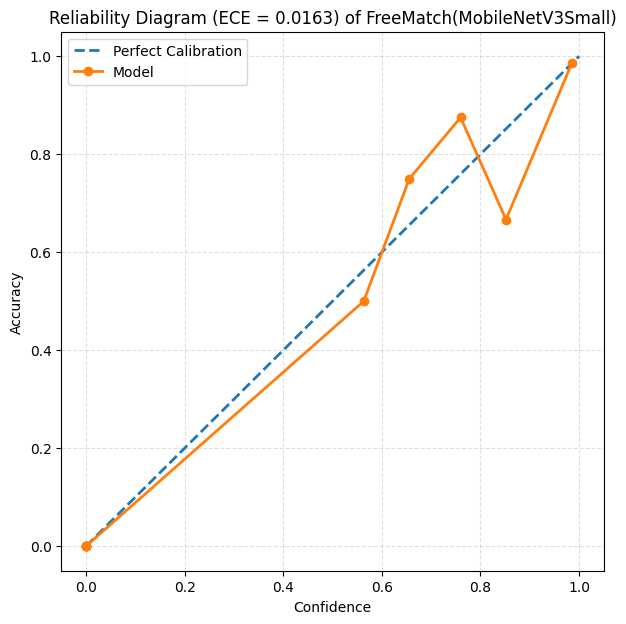

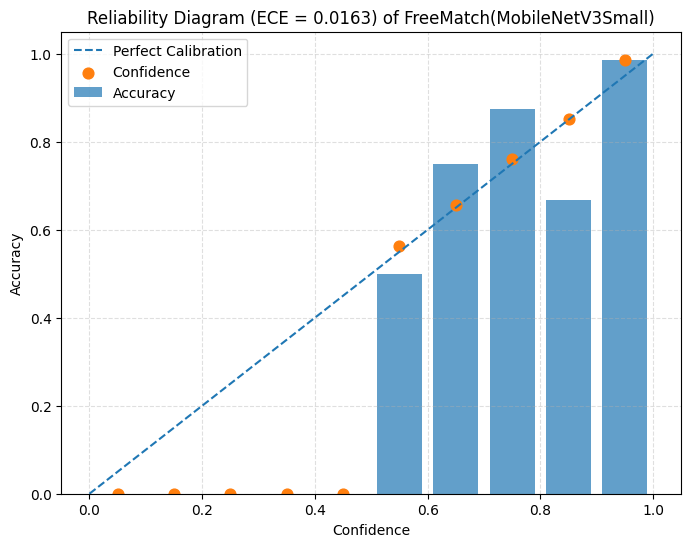

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ PREDICTIONS
# =========================================================

y_prob = mean_preds

y_pred = np.argmax(y_prob, axis=1)
y_true = true_labels

confidences = np.max(y_prob, axis=1)
correct = (y_pred == y_true).astype(int)

# =========================================================
# 2️⃣ ECE COMPUTATION
# =========================================================

n_bins = 10
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

ece = 0.0

bin_acc = []
bin_conf = []
bin_counts = []

for i in range(n_bins):

    bin_lower = bin_edges[i]
    bin_upper = bin_edges[i + 1]

    in_bin = (confidences > bin_lower) & (confidences <= bin_upper)

    bin_size = np.sum(in_bin)

    if bin_size > 0:

        accuracy = np.mean(correct[in_bin])
        confidence = np.mean(confidences[in_bin])

        bin_acc.append(accuracy)
        bin_conf.append(confidence)
        bin_counts.append(bin_size)

        ece += (bin_size / len(confidences)) * abs(accuracy - confidence)

    else:
        bin_acc.append(0)
        bin_conf.append(0)
        bin_counts.append(0)

print(f"\nECE (Expected Calibration Error): {ece:.4f}")

# =========================================================
# 3️⃣ RELIABILITY DIAGRAM (LINE PLOT)
# =========================================================

plt.figure(figsize=(7,7))

plt.plot([0, 1], [0, 1], '--', linewidth=2, label="Perfect Calibration")

plt.plot(
    bin_conf,
    bin_acc,
    marker='o',
    linewidth=2,
    label="Model"
)

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE = {ece:.4f}) of FreeMatch(MobileNetV3Small)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.show()

# =========================================================
# 4️⃣ RELIABILITY DIAGRAM (BAR + CONFIDENCE)
# =========================================================

plt.figure(figsize=(8,6))

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(
    bin_centers,
    bin_acc,
    width=0.08,
    alpha=0.7,
    label="Accuracy"
)

plt.plot([0,1],[0,1],'--',label="Perfect Calibration")

plt.scatter(
    bin_centers,
    bin_conf,
    s=60,
    label="Confidence"
)

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE = {ece:.4f}) of FreeMatch(MobileNetV3Small)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()